In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
cursor.execute(
"""CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [4]:
cursor.executemany("""
INSERT INTO sales (product, quantity, price)
VALUES (?, ?, ?)
""", [
    ("Laptop", 5, 50000),
    ("Mouse", 10, 500),
    ("Keyboard", 7, 1500),
    ("Laptop", 3, 52000),
    ("Mouse", 5, 450)
])

conn.commit()

In [9]:
query = """
SELECT 
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

In [8]:
df = pd.read_sql_query(query, conn)
print(df)

    product  total_qty   revenue
0  Keyboard          7   10500.0
1    Laptop          8  406000.0
2     Mouse         15    7250.0


In [14]:
query2 = """
SELECT 
    product,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC
LIMIT 1
"""

df2 = pd.read_sql_query(query2, conn)
print("\nTop Revenue Product:")
print(df2)


Top Revenue Product:
  product   revenue
0  Laptop  406000.0


In [15]:
query3 = """
SELECT 
    SUM(quantity) AS overall_quantity,
    SUM(quantity * price) AS overall_revenue
FROM sales
"""

df3 = pd.read_sql_query(query3, conn)
print("\nOverall Sales Summary:")
print(df3)


Overall Sales Summary:
   overall_quantity  overall_revenue
0                30         423750.0


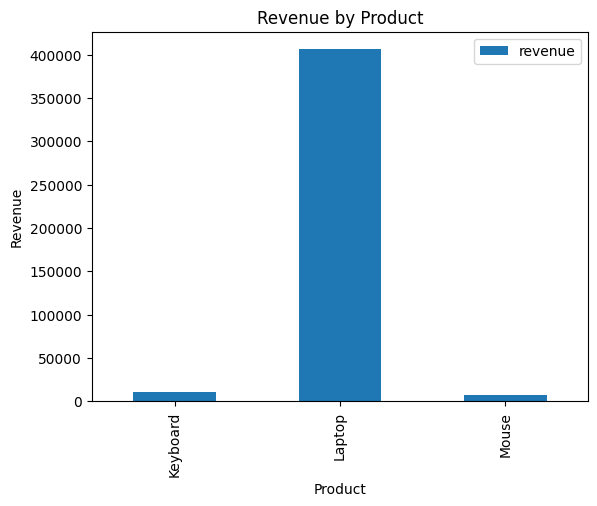

In [18]:
df.plot(kind='bar', x='product', y='revenue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [19]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>